## Cell 1 — Imports and config

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point

CRIME_CSV        = r'london_crime_2025.csv'
CRS_METRIC       = 'EPSG:27700'
GRID_M           = 200

SEVERITY_ORDER   = ['Low', 'Medium', 'High']
SEVERITY_COLORS  = {'Low': "#FFF71A", 'Medium': '#FF9800', 'High': '#F44336'}
SEVERITY_WEIGHTS = {'Low': 1, 'Medium': 2, 'High': 3}

## Cell 2 — Load crime data

In [2]:
crimes = pd.read_csv(CRIME_CSV)
print(f'Total rows: {len(crimes):,}')

# Drop unclassified rows (NaN severity)
crimes = crimes.dropna(subset=['severity_class'])
print(f'Classified rows: {len(crimes):,}')
print()
print(crimes['severity_class'].value_counts())

# Convert to GeoDataFrame and reproject
geometry   = gpd.points_from_xy(crimes['longitude'], crimes['latitude'])
crimes_gdf = gpd.GeoDataFrame(crimes, geometry=geometry, crs='EPSG:4326')
crimes_m   = crimes_gdf.to_crs(CRS_METRIC).copy()
crimes_m['x']      = crimes_m.geometry.x
crimes_m['y']      = crimes_m.geometry.y

# Map severity to category for exponential scoring
crimes_m['category'] = crimes_m['severity_class'].map({
    'Low': 'Petty',
    'Medium': 'Medium',
    'High': 'Serious'
})

print(f'\nReprojected to {CRS_METRIC} — ready for plotting.')

Total rows: 1,140,416
Classified rows: 984,760

severity_class
Low       521231
High      301447
Medium    162082
Name: count, dtype: int64

Reprojected to EPSG:27700 — ready for plotting.


In [3]:
# ── Exponential crime scoring helper function ──────────────────────────────
def calculate_exponential_crime_score(petty_count, medium_count, serious_count):
    """
    Calculate exponential crime score from category counts using log-transformed exponents.
    
    Formula: score = 1.3^log(petty+1) + 2.0^log(medium+1) + 3.0^log(serious+1)
    
    The log transform moderates exponential growth while preserving the relative weighting
    of serious crimes. Adding 1 before logging ensures that 0 crimes → log(1)=0 → base^0=1
    (which maps to a score contribution of 0).
    
    Args:
        petty_count, medium_count, serious_count: Crime counts in each category (>=0)
    
    Returns:
        float: Combined crime score (always >= 0)
    """
    # Log-transform counts and compute exponential components
    # log(count + 1) ensures 0 → log(1) = 0, so base^0 = 1, then we subtract 1 to get 0
    petty_exp = 1.3 ** np.log(petty_count + 1)
    medium_exp = 2.0 ** np.log(medium_count + 1)
    serious_exp = 3.0 ** np.log(serious_count + 1)
    
    # Subtract 1 from each to map count=0 → contribution=0
    petty_score = petty_exp - 1
    medium_score = medium_exp - 1
    serious_score = serious_exp - 1
    
    return petty_score + medium_score + serious_score

## Cell 3 — Severity breakdown

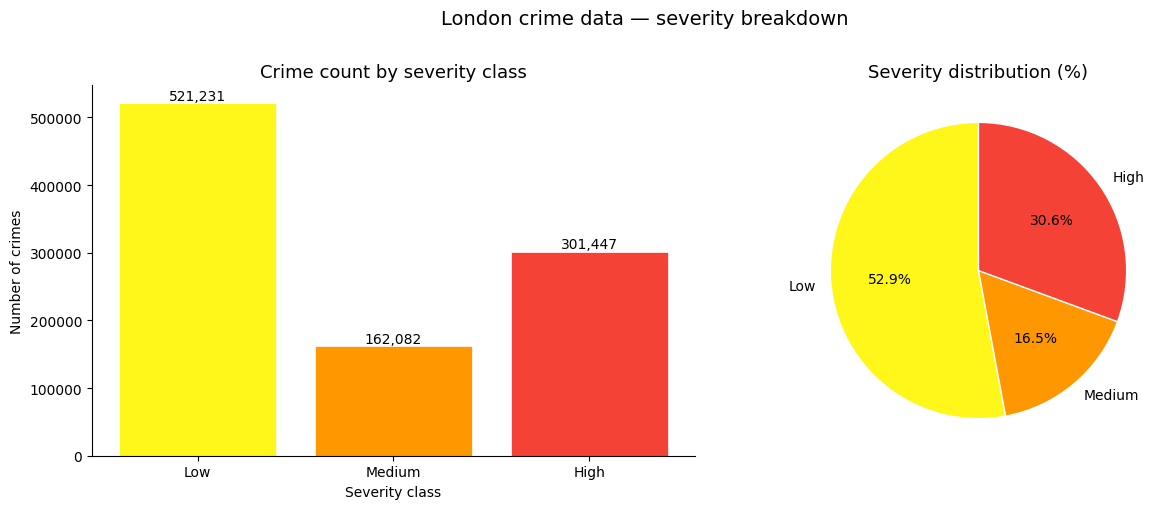

In [4]:
counts = crimes_m['severity_class'].value_counts().reindex(SEVERITY_ORDER)
colors  = [SEVERITY_COLORS[s] for s in SEVERITY_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(SEVERITY_ORDER, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Crime count by severity class', fontsize=13)
axes[0].set_xlabel('Severity class')
axes[0].set_ylabel('Number of crimes')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=SEVERITY_ORDER, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1)
)
for at in autotexts:
    at.set_fontsize(10)
axes[1].set_title('Severity distribution (%)', fontsize=13)

plt.suptitle('London crime data — severity breakdown', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Cell 4 — Spatial plots
#### Hexbin density per severity class (Low / Medium / High). Each hexagon shows how many crimes of that class fell inside it.

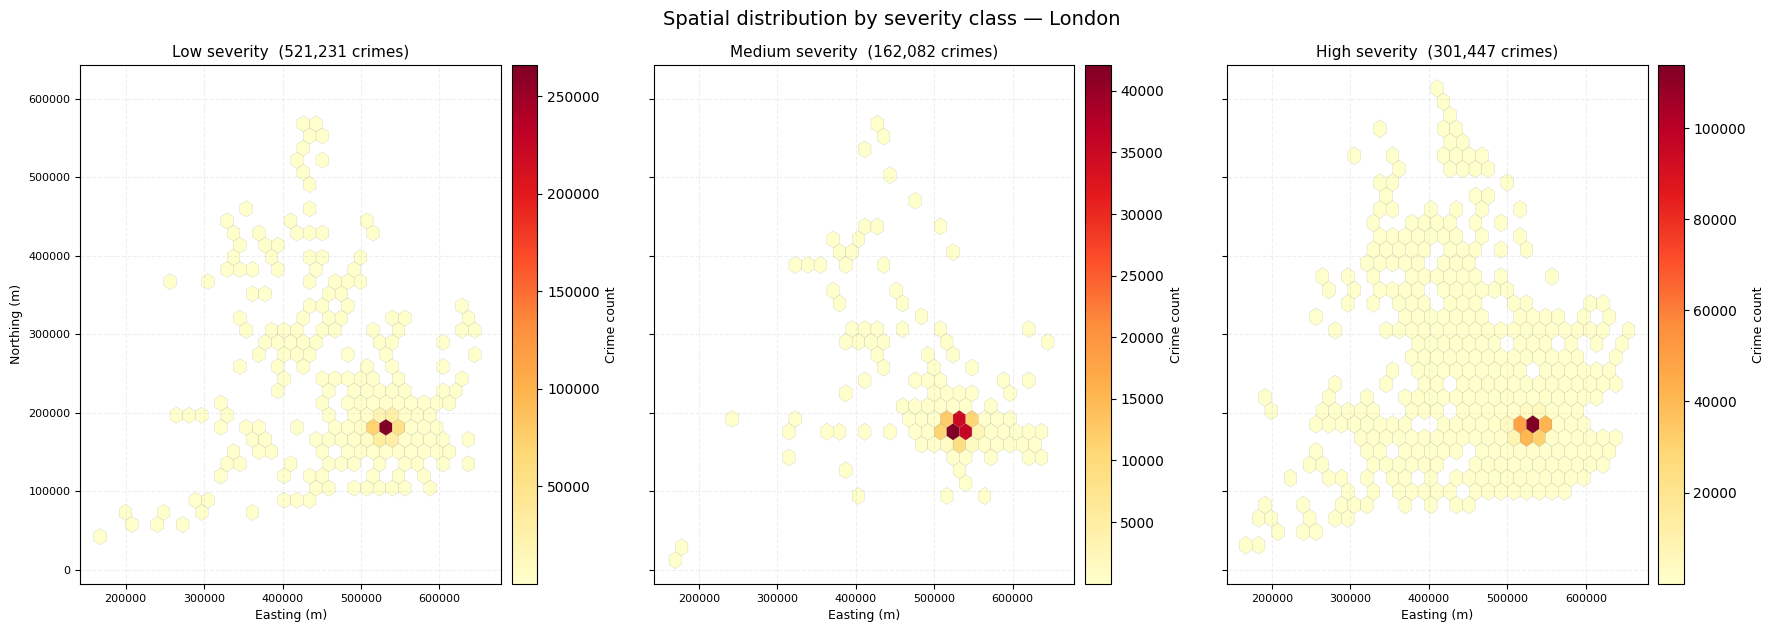

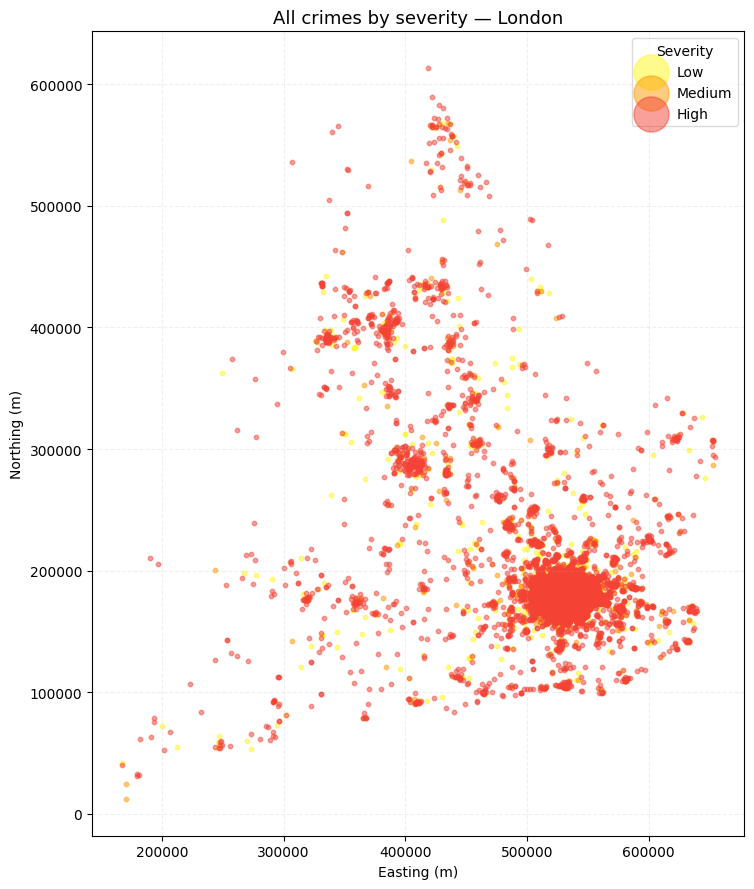

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, sev in zip(axes, SEVERITY_ORDER):
    sub = crimes_m[crimes_m['severity_class'] == sev]
    hb = ax.hexbin(sub['x'], sub['y'], gridsize=30, cmap='YlOrRd', mincnt=1, 
               linewidths=0.1, edgecolors='gray', alpha=1)
    cb  = plt.colorbar(hb, ax=ax, pad=0.02)
    cb.set_label('Crime count', fontsize=9)
    ax.set_title(f'{sev} severity  ({len(sub):,} crimes)', fontsize=11)
    ax.set_xlabel('Easting (m)', fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Northing (m)', fontsize=9)
plt.suptitle('Spatial distribution by severity class — London', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# All classes overlaid on one map
fig2, ax2 = plt.subplots(figsize=(9, 9))
for sev in SEVERITY_ORDER:
    sub = crimes_m[crimes_m['severity_class'] == sev]
    ax2.scatter(sub['x'], sub['y'], s=10, alpha=0.5, color=SEVERITY_COLORS[sev],
                label=sev, rasterized=True)
ax2.set_title('All crimes by severity — London', fontsize=13)
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.legend(markerscale=8, title='Severity', framealpha=0.7)
plt.tight_layout()
plt.show()

## Cell 4b — Single hexgrid colored by total crime density
#### All crimes combined into one hexbin, with color intensity representing the total crime count per cell.


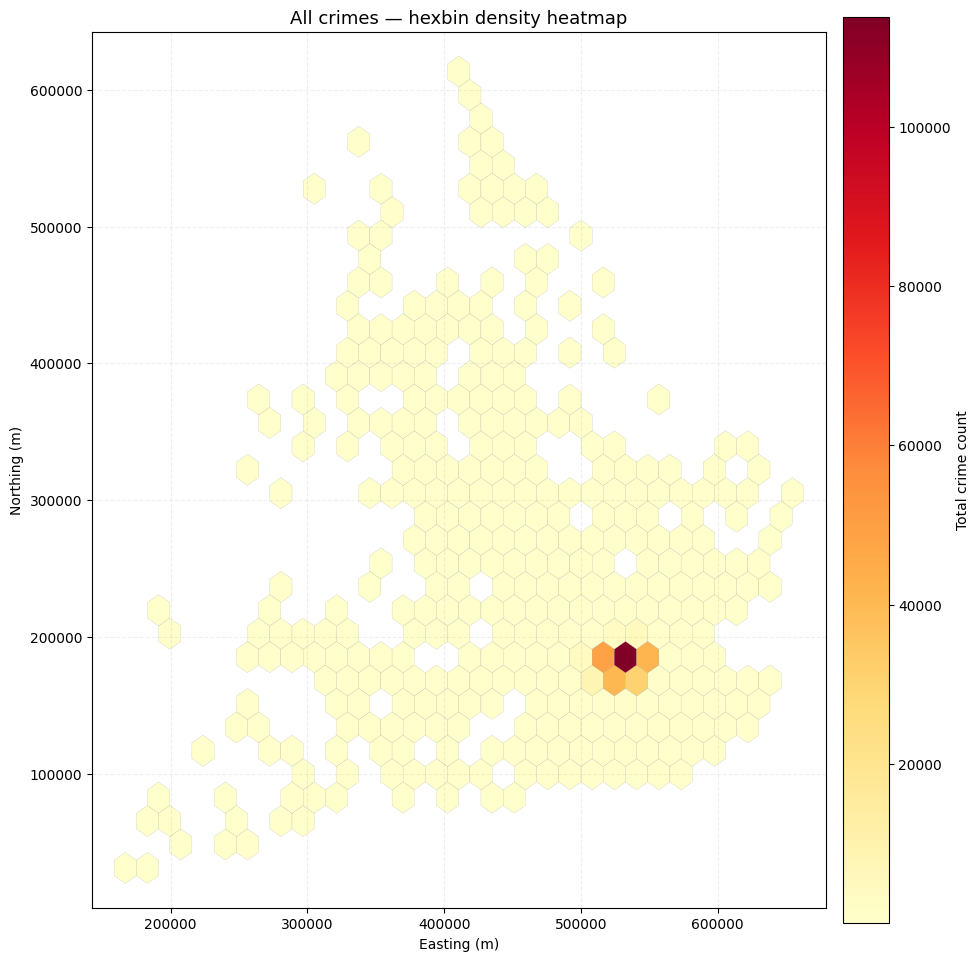

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

# Single hexbin with all crimes, colored by count
hb = ax.hexbin(sub['x'], sub['y'], gridsize=30, cmap='YlOrRd', mincnt=1, 
    linewidths=0.1, edgecolors='gray', alpha=1)
cb = plt.colorbar(hb, ax=ax, pad=0.02)
cb.set_label('Total crime count', fontsize=10)

ax.set_title('All crimes — hexbin density heatmap', fontsize=13)
ax.set_xlabel('Easting (m)', fontsize=10)
ax.set_ylabel('Northing (m)', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

## Cell 5 — Distribution of crime density per grid cell
#### Crimes are bucketed into a regular 200 m grid as a proxy for per-segment distribution. The log-scale y-axis reveals the long right tail. The printed thresholds show what equal-width binning would produce.

### Cell 5b — Log-Transformed Exponential Crime Score Definition

The **exponential crime score** uses log-transformed exponents to moderate growth while preserving severity weighting:

$$\text{score} = 1.3^{\ln(\text{petty}+1)} + 2.0^{\ln(\text{medium}+1)} + 3.0^{\ln(\text{serious}+1)} - 3$$

where $\ln$ is the natural logarithm. The $-3$ term ensures that 0 crimes → score = 0.

**Why log-transform?** Without the log transform, high crime counts (50+) produce astronomical scores. The logarithmic exponent moderates this while preserving the exponential growth pattern and severity weighting.

**Key properties:**
- 0 crimes → score = 0 (safe baseline)
- Serious crimes grow faster than petty crimes (base 3.0 vs. 1.3)
- Scores remain numerically stable across all real data ranges
- A neighborhood with 1 serious crime (≈0.33) is more serious than 10 petty crimes (≈0.56)

Example: A cell with 20 Petty + 5 Medium + 10 Serious crimes has a score of:
$$1.3^{\ln(21)} + 2.0^{\ln(6)} + 3.0^{\ln(11)} - 3 ≈ 1.48 + 2.47 + 6.12 - 3 = 7.07$$

In [7]:
crimes_m['gx'] = (crimes_m['x'] // GRID_M).astype(int)
crimes_m['gy'] = (crimes_m['y'] // GRID_M).astype(int)

# Count crimes by category per grid cell
raw_counts = crimes_m.groupby(['gx', 'gy']).size().rename('crime_count')
category_counts = crimes_m.groupby(['gx', 'gy', 'category']).size().unstack(fill_value=0)

# Ensure all categories exist
for cat in ['Petty', 'Medium', 'Serious']:
    if cat not in category_counts.columns:
        category_counts[cat] = 0

# Apply exponential formula
crime_scores = category_counts.apply(
    lambda row: calculate_exponential_crime_score(row['Petty'], row['Medium'], row['Serious']),
    axis=1
).rename('crime_score')

grid = pd.concat([raw_counts, crime_scores], axis=1).reset_index()

print(f'Grid cells with at least 1 crime : {len(grid):,}')
print(f'Max raw count in a cell          : {grid["crime_count"].max()}')
print(f'Max exponential score in a cell  : {grid["crime_score"].max():.1f}')
print(f'Median raw count                 : {grid["crime_count"].median():.1f}')

Grid cells with at least 1 crime : 27,901
Max raw count in a cell          : 2992
Max exponential score in a cell  : 979.9
Median raw count                 : 15.0


## Grid Score Validation

The exponential formula creates significant score growth compared to the old linear weighting approach. This cell validates the score distribution.

In [14]:
print('=== Exponential vs. Linear Scoring Comparison ===\n')
print('Crime Config             | Log-Transform Score | Old Linear Score')
print('-' * 66)

configs = [
    ('0 crimes', 0, 0, 0),
    ('1 Low', 1, 0, 0),
    ('5 Low', 5, 0, 0),
    ('10 Low', 10, 0, 0),
    ('50 Low', 50, 0, 0),
    ('1 Medium', 0, 1, 0),
    ('5 Medium', 0, 5, 0),
    ('20 Medium', 0, 20, 0),
    ('1 High', 0, 0, 1),
    ('5 High', 0, 0, 5),
    ('20 High', 0, 0, 20),
    ('1L + 1M + 1H', 1, 1, 1),
    ('10L + 5M + 3H', 10, 5, 3),
    ('50L + 20M + 10H', 50, 20, 10),
]

for desc, petty, medium, serious in configs:
    exp_score = calculate_exponential_crime_score(petty, medium, serious)
    # Old linear scoring: Low=1, Medium=2, High=3
    old_score = petty * 1 + medium * 2 + serious * 3
    print(f'{desc:20s} | {exp_score:19.4f} | {old_score:16.0f}')

=== Exponential vs. Linear Scoring Comparison ===

Crime Config             | Log-Transform Score | Old Linear Score
------------------------------------------------------------------
0 crimes             |              0.0000 |                0
1 Low                |              0.1994 |                1
5 Low                |              0.6001 |                5
10 Low               |              0.8760 |               10
50 Low               |              1.8055 |               50
1 Medium             |              0.6168 |                2
5 Medium             |              2.4624 |               10
20 Medium            |              7.2507 |               40
1 High               |              1.1415 |                3
5 High               |              6.1596 |               15
20 High              |             27.3535 |               60
1L + 1M + 1H         |              1.9577 |                6
10L + 5M + 3H        |              6.9243 |               29
50L + 20M 

## Cell 6 Threshold Printdown

We are checking which way to bin for the classification would make sense. Seeing the result and the amount of street segments that land on 0 crimes, equal-width binning will fail on data. 
With equal-width cuts, the "safe" class captures 99.9% of all grid cells — leaving almost nothing for the model to learn from in the neutral and unsafe classes. This happens because crime counts follow a heavily  skewed distribution: most areas have very few crimes, and a handful of hotspots have extreme counts. Splitting the range into three equal intervals puts nearly everything in the first bin.

The ML notebook (02) addresses this by treating 0-crime segments as their own "safe" class, then splitting the remaining non-zero segments at the median. This produces a balanced distribution (~58% safe / ~21% neutral / ~21% dangerous) that gives the classifier enough examples of each class to learn from.

In [15]:
for col, label in [('crime_count', 'Raw count'), ('crime_score', 'Weighted score')]:
    mn, mx = grid[col].min(), grid[col].max()
    t1, t2 = mn + (mx - mn) / 3, mn + 2 * (mx - mn) / 3
    safe_n    = (grid[col] <= t1).sum()
    neutral_n = ((grid[col] > t1) & (grid[col] <= t2)).sum()
    unsafe_n  = (grid[col] > t2).sum()
    print(f'\n{label}  —  equal-width thresholds: {t1:.1f} / {t2:.1f}')
    print(f'  Safe    : {safe_n:,} cells  ({100*safe_n/len(grid):.1f}%)')
    print(f'  Neutral : {neutral_n:,} cells  ({100*neutral_n/len(grid):.1f}%)')
    print(f'  Unsafe  : {unsafe_n:,} cells  ({100*unsafe_n/len(grid):.1f}%)')


Raw count  —  equal-width thresholds: 998.0 / 1995.0
  Safe    : 27,880 cells  (99.9%)
  Neutral : 15 cells  (0.1%)
  Unsafe  : 6 cells  (0.0%)

Weighted score  —  equal-width thresholds: 326.8 / 653.3
  Safe    : 27,856 cells  (99.8%)
  Neutral : 40 cells  (0.1%)
  Unsafe  : 5 cells  (0.0%)


## Cell 7 — Islington focus
#### Zoom in on Islington borough only for detailed hexbin analysis

Total crimes in Islington: 35,925
Breakdown by severity:
severity_class
Low       20749
Medium     5728
High       9448
Name: count, dtype: int64


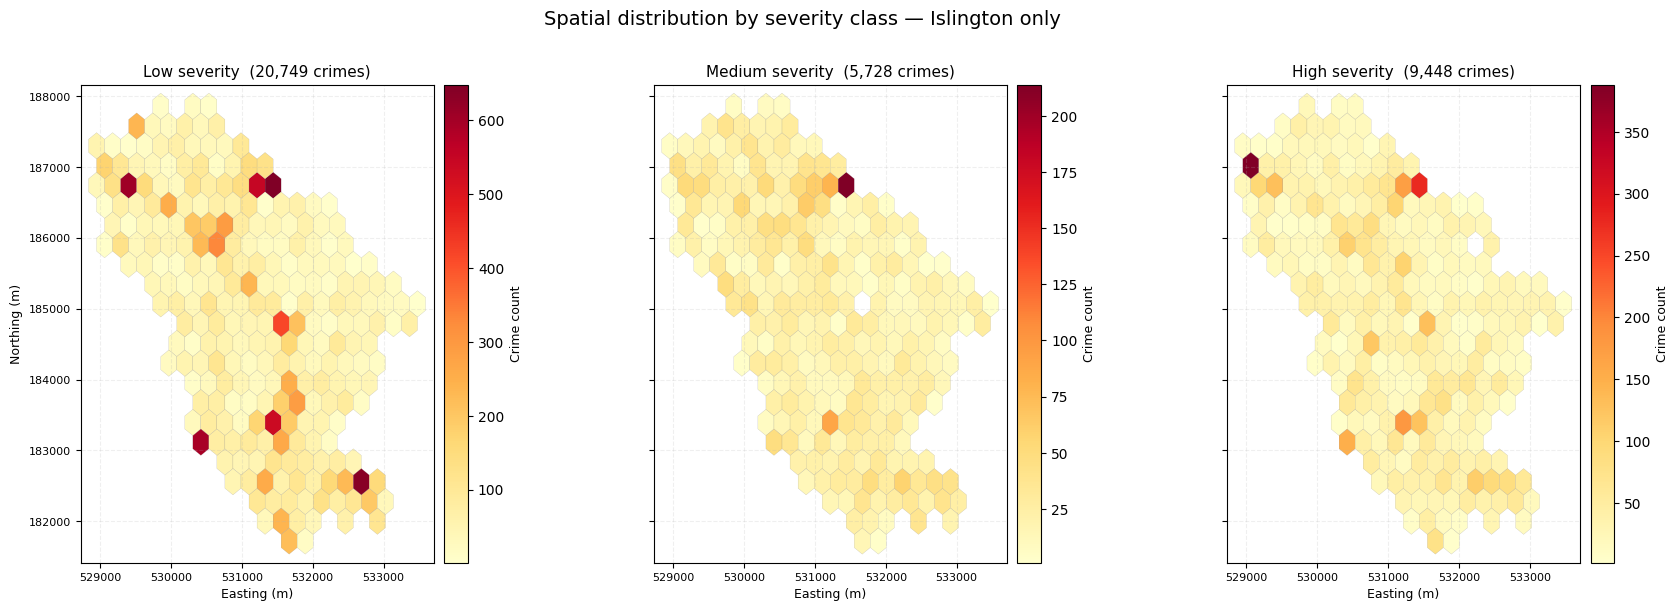

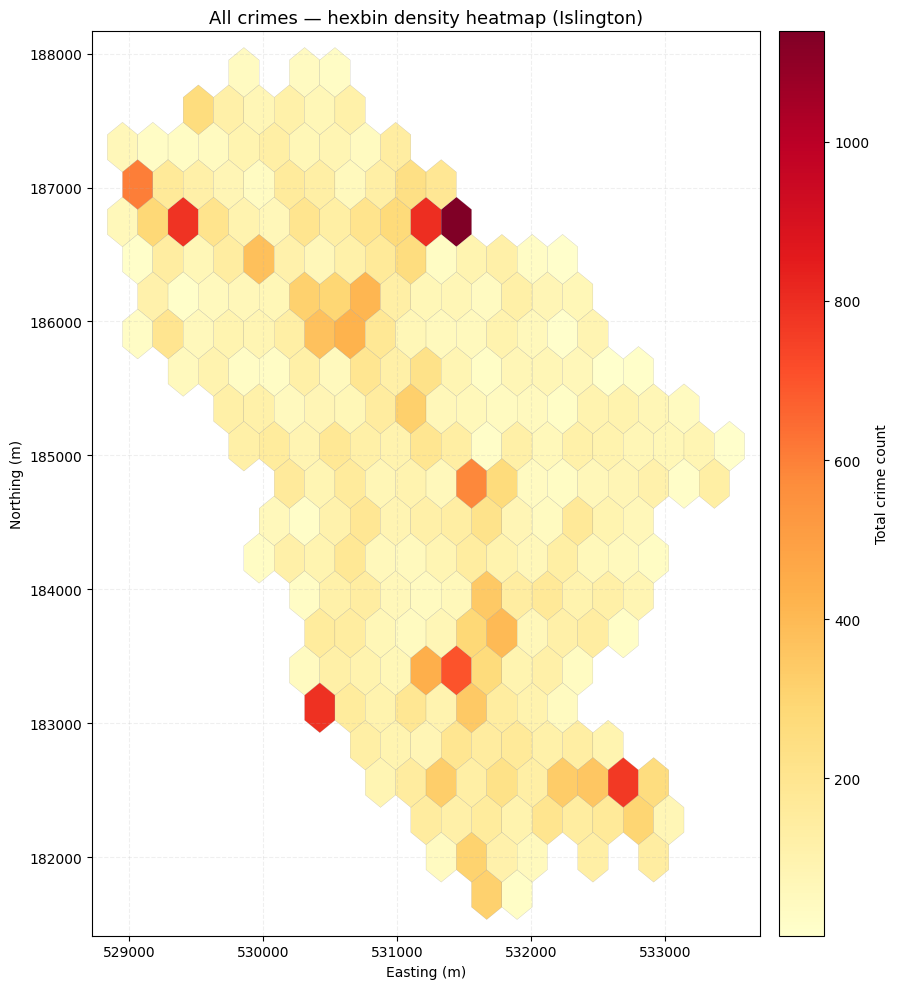

In [16]:
# Filter crimes to Islington only
islington_crimes = crimes_m[crimes_m['lsoa_name'].str.contains('Islington', case=False, na=False)].copy()
print(f'Total crimes in Islington: {len(islington_crimes):,}')
print(f'Breakdown by severity:')
print(islington_crimes['severity_class'].value_counts().reindex(SEVERITY_ORDER))

# Create hexbin subplot for each severity class (Islington only)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, sev in zip(axes, SEVERITY_ORDER):
    sub = islington_crimes[islington_crimes['severity_class'] == sev]
    hb = ax.hexbin(sub['x'], sub['y'], gridsize=20, cmap='YlOrRd', mincnt=1, 
                   linewidths=0.1, edgecolors='gray', alpha=1)
    cb = plt.colorbar(hb, ax=ax, pad=0.02)
    cb.set_label('Crime count', fontsize=9)
    ax.set_title(f'{sev} severity  ({len(sub):,} crimes)', fontsize=11)
    ax.set_xlabel('Easting (m)', fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Northing (m)', fontsize=9)
plt.suptitle('Spatial distribution by severity class — Islington only', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Single hexbin for all crimes in Islington combined
fig2, ax2 = plt.subplots(figsize=(10, 10))
hb2 = ax2.hexbin(islington_crimes['x'], islington_crimes['y'], gridsize=20, cmap='YlOrRd', 
                  mincnt=1, linewidths=0.1, edgecolors='gray', alpha=1)
cb2 = plt.colorbar(hb2, ax=ax2, pad=0.02)
cb2.set_label('Total crime count', fontsize=10)

ax2.set_title('All crimes — hexbin density heatmap (Islington)', fontsize=13)
ax2.set_xlabel('Easting (m)', fontsize=10)
ax2.set_ylabel('Northing (m)', fontsize=10)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

## Top Crime Segments — Real-world Coordinates

Extract the highest crime segments with their lat/lon coordinates for ground-truth field validation.

In [19]:
# Extract top crime segments with real-world coordinates for ground-truth checking
print('=== TOP 20 HIGHEST CRIME SEGMENTS — ISLINGTON ONLY (IRL COORDINATES) ===\n')

# Group ISLINGTON crimes by their grid cell location, compute scores
grid_crimes = pd.crosstab(
    index=islington_crimes.geometry.apply(lambda x: f"{int(x.x // GRID_M)},{int(x.y // GRID_M)}"),
    columns=islington_crimes['category'],
    margins=False
)
grid_crimes = grid_crimes.fillna(0)

# Calculate exponential crime scores for each grid cell
grid_scores = []
for idx, row in grid_crimes.iterrows():
    score = calculate_exponential_crime_score(
        row.get('Petty', 0),
        row.get('Medium', 0),
        row.get('Serious', 0)
    )
    grid_scores.append(score)

grid_crimes['crime_score'] = grid_scores

# Apply fixed-threshold binning (0-50 neutral, 50-150 unsafe, 150+ critical)
def assign_safety_class(score):
    if score < 50:
        return 'neutral'
    elif score < 150:
        return 'unsafe'
    else:
        return 'critical'

grid_crimes['safety_class'] = grid_crimes['crime_score'].apply(assign_safety_class)

print('Safety class distribution (fixed thresholds):')
print(f'  neutral  (0-50)      : {(grid_crimes["safety_class"] == "neutral").sum():,} cells')
print(f'  unsafe   (50-150)    : {(grid_crimes["safety_class"] == "unsafe").sum():,} cells')
print(f'  critical (150+)      : {(grid_crimes["safety_class"] == "critical").sum():,} cells')
print()

# Get top 20 grid cells
top_20_idx = grid_crimes.nlargest(20, 'crime_score').index
result_rows = []

for cell_id in top_20_idx:
    x_idx, y_idx = map(int, cell_id.split(','))
    centroid_x = x_idx * GRID_M + GRID_M / 2
    centroid_y = y_idx * GRID_M + GRID_M / 2
    
    # Convert to WGS84 (lat/lon)
    point_metric = Point(centroid_x, centroid_y)
    point_gdf = gpd.GeoDataFrame([1], geometry=[point_metric], crs=CRS_METRIC)
    point_wgs = point_gdf.to_crs('EPSG:4326')
    lat, lon = point_wgs.geometry.iloc[0].y, point_wgs.geometry.iloc[0].x
    
    score = grid_crimes.loc[cell_id, 'crime_score']
    safety_class = grid_crimes.loc[cell_id, 'safety_class']
    result_rows.append({
        'rank': len(result_rows) + 1,
        'crime_score': score,
        'safety_class': safety_class,
        'latitude': lat,
        'longitude': lon
    })

result_df = pd.DataFrame(result_rows)
print('=== TOP 20 HIGHEST CRIME SEGMENTS (IRL COORDINATES) ===\n')
print(result_df.to_string(index=False))
print('\n✓ Copy-paste these lat/lon pairs into Google Maps or your GIS tool')
print('  Format: "latitude, longitude" (e.g., 51.5234, -0.1234)\n')

# Also save as CSV for easy import
result_df.to_csv('top_20_crime_segments_islington.csv', index=False)
print('✓ Saved to: top_20_crime_segments_islington.csv')

=== TOP 20 HIGHEST CRIME SEGMENTS — ISLINGTON ONLY (IRL COORDINATES) ===

Safety class distribution (fixed thresholds):
  neutral  (0-50)      : 278 cells
  unsafe   (50-150)    : 89 cells
  critical (150+)      : 8 cells

=== TOP 20 HIGHEST CRIME SEGMENTS (IRL COORDINATES) ===

 rank  crime_score safety_class  latitude  longitude
    1   661.783409     critical 51.566205  -0.138786
    2   528.078274     critical 51.563854  -0.104255
    3   278.917589     critical 51.533393  -0.111288
    4   213.375100     critical 51.546020  -0.113650
    5   210.071863     critical 51.527768  -0.097104
    6   162.138215     critical 51.558694  -0.118896
    7   155.333021     critical 51.531734  -0.120007
    8   153.951686     critical 51.562149  -0.110097
    9   143.304930       unsafe 51.566159  -0.135902
   10   139.474158       unsafe 51.545881  -0.105002
   11   137.666252       unsafe 51.533300  -0.105524
   12   132.974862       unsafe 51.520672  -0.103166
   13   130.139101       unsafe

In [20]:
import pandas as pd

df = pd.read_csv('top_20_crime_segments_islington.csv')  # Must have 'longitude', 'latitude' columns

kml_content = """<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
  <Document>
    <name>My Pins</name>
"""

for idx, row in df.iterrows():
    kml_content += f"""
    <Placemark>
      <name>{row.get('name', f'Pin {idx}')}</name>
      <description>{row.get('description', '')}</description>
      <Point>
        <coordinates>{row['longitude']},{row['latitude']},0</coordinates>
      </Point>
    </Placemark>
"""

kml_content += """
  </Document>
</kml>
"""

with open('pins.kml', 'w') as f:
    f.write(kml_content)

print("✓ KML file created: pins.kml")

✓ KML file created: pins.kml
